### **k-means clustering**

####  is a algorithm used to group data points into clusters based on their similarities.  , 

#### k =no of clusters   

#### Centroid = mean of the points in one cluster ( where more data points shifts towards the centroid)

#### k no of centroid points are randomly selected and then the data points are assigned to the nearest centroid based on distance (Euclidean distance) and then the centroid is recalculated based on the new cluster points. 
###  Example : 
 1 2 3       >      20 21 22  >           40 41 42
 
 C1     >>>>               C2          >>>>         C3




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

In [3]:
df = load_iris(as_frame = True).frame  # as_frame -> pandas dataframes 
df 

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [5]:
X = df[['sepal length (cm)','sepal width (cm)']] # for simple example 
X.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [6]:
scaler =StandardScaler()
X_scaled = scaler.fit_transform(X)


#K-Means clustering is sensitive to the scale of the features. To ensure 
# that all features contribute equally to the distance calculations, we use
# StandardScaler to standardize the features. This transforms the data so t
# hat it has a mean of 0 and a standard deviation of 1.

In [7]:
kmeans= KMeans ( n_clusters =3 ,  # no of cluster , 
                init ='k-means++' ,  #This is a smart initialization technique that helps to c
                                  #converge faster and avoid suboptimal solutions.
                max_iter =300 ,   # maximum number of iterations for a single run
                random_state = 42 ) # ensure reproducibility

In [9]:
kmeans.fit(X_scaled)  # Fit the model on scaled data
print(kmeans.labels_[:100]) # first 100 labels

[2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 1 2 2 2 2 2 2 2 2 0 0 0 1 0 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 0 0 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 1]


In [15]:
df['cluster'] = kmeans.labels_
df.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,Cluster,cluster
0,5.1,3.5,1.4,0.2,0,2,2
1,4.9,3.0,1.4,0.2,0,2,2
2,4.7,3.2,1.3,0.2,0,2,2
3,4.6,3.1,1.5,0.2,0,2,2
4,5.0,3.6,1.4,0.2,0,2,2
5,5.4,3.9,1.7,0.4,0,2,2
6,4.6,3.4,1.4,0.3,0,2,2
7,5.0,3.4,1.5,0.2,0,2,2
8,4.4,2.9,1.4,0.2,0,2,2
9,4.9,3.1,1.5,0.1,0,2,2


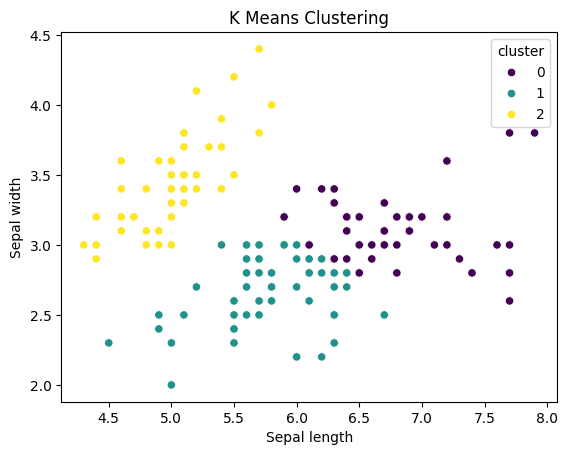

In [16]:
sns.scatterplot(
    x = df['sepal length (cm)'],
    y = df['sepal width (cm)'],
    hue = df['cluster'],
    palette = 'viridis'
)

plt.title("K Means Clustering")
plt.xlabel("Sepal length")
plt.ylabel("Sepal width")
plt.show()

 ###  ***how centroid is calculated :*** (Only for K means++)

 #### Pick the first centroid randomly.

#### Pick the second centroid far away from the first (using weighted probability).

#### (here farest point from centroid 1 is more likey to get selected as centroid 2)

#### Pick the third centroid far away from the first two.

#### Continue until all K centroids are chosen.

##  ***how centroid is calculated :*** (Only for K means Clustering )

#### 1. Randomly select K points as initial centroids.
#### 2. Assign each data point to the nearest centroid based on Euclidean distance.
#### 3. Update the centroids by calculating the mean of all the data points assigned to each cluster / groups 
#### 4. recalculate all the data points to the nearest centroid and reassign them to the new clusters.
####  ***Repeat steps 3 and 4 until the centroids do not change significantly or a maximum number of iterations is reached.***

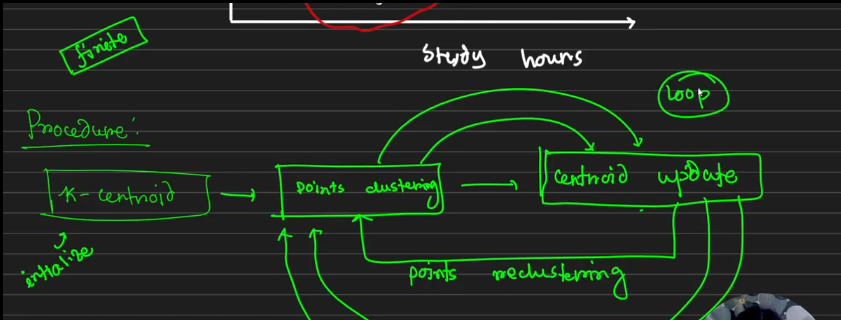

In [2]:
from IPython.display import Image, display


display(Image(filename='Clustering.png'))

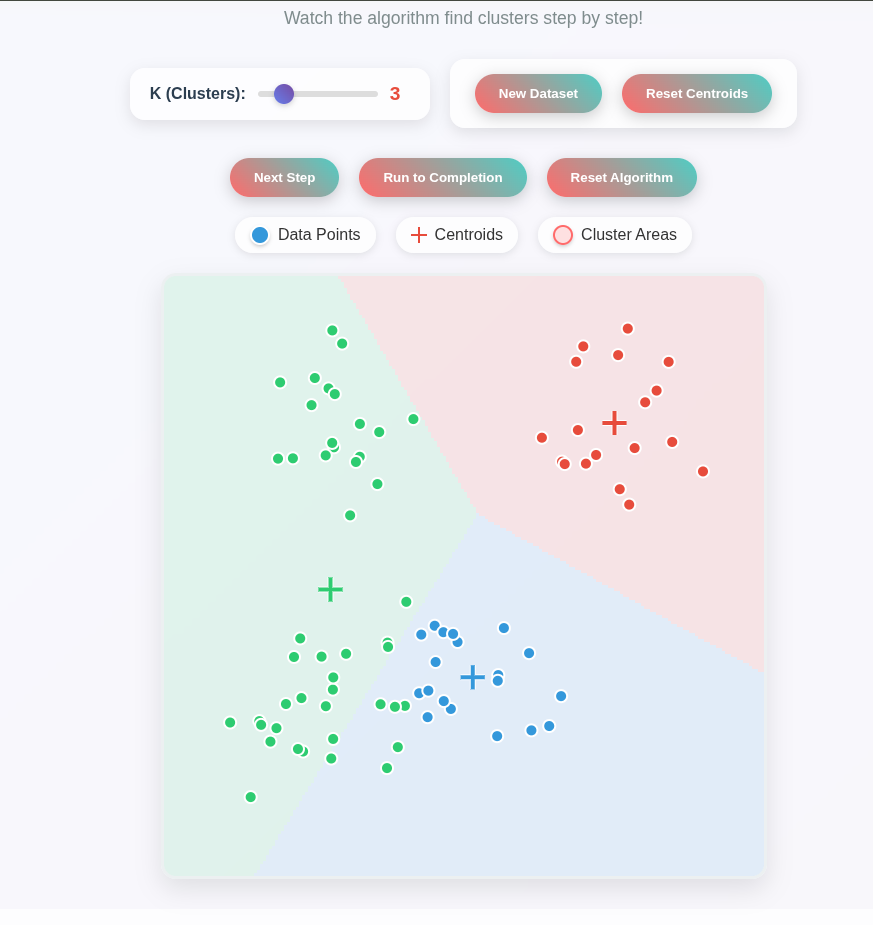

In [3]:
from IPython.display import Image, display


display(Image(filename='interactive_ui_2.png'))

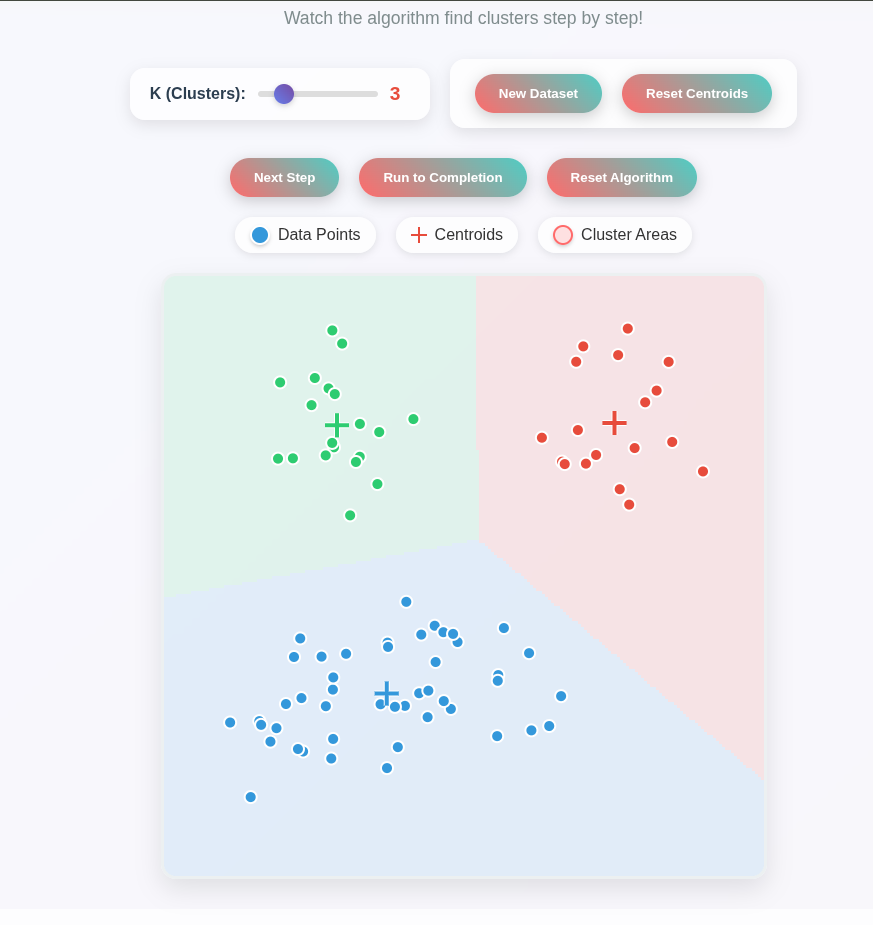

In [4]:
from IPython.display import Image, display


display(Image(filename='interactive_ui_3.png'))

### Cost Function :

#### 1.  (c-xi)^2  (where c is the centroid and xi is the data point)  ---  this is the distance between the centroid and the data point. -- for all data points in that cluster

#### 2. SSE = SSE of all clusters = sum of (c-xi)^2  for all clusters

#### 3. if SSE decreases then the clustering is good otherwise not 

#### 4. if SSE remains same then it converged and stop the iterations